# IT Job Demand Forecasting using Time Series Models
---
### 📌 Project Flow (Box-Jenkins Procedure)
1. **Load & Visualize** the raw time series
2. **Identification** — Check stationarity (ADF test), plot ACF & PACF to choose p, d, q
3. **Estimation** — Fit  models: ARIMA and SARIMA
4. **Verification** — Check residuals (White Noise / Ljung-Box test)
5. **Forecasting** — Forecast next 14 days


## Step 0: Import Libraries and Load Dataset

In [ ]:
# ==========================================
# IT JOB DEMAND FORECASTING (LINKEDIN DATA)
# Box-Jenkins Methodology Pipeline
# ==========================================

import os
import warnings
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox

# Suppress warnings for clean output during presentation
warnings.filterwarnings("ignore")
plt.style.use('seaborn-v0_8-darkgrid')

# ---------------------------------------------------------
# DATA ACQUISITION & PREPARATION
# ---------------------------------------------------------

print("Downloading dataset from Kaggle...")
path = kagglehub.dataset_download("sindhumadhurii/linkedin-job-posts-insights-dataset")
print("Path to dataset files:", path)

# Locate the Excel file in the downloaded dataset
excel_files = [f for f in os.listdir(path) if f.endswith('.xlsx') or f.endswith('.xls')]
if not excel_files:
    raise FileNotFoundError("No Excel file found in the downloaded dataset!")

file_path = os.path.join(path, excel_files[0])
print(f"Loading data from: {file_path}\n")

# Read the dataset using read_excel
df = pd.read_excel(file_path)

df['job_function'] = df['job_function'].fillna('')
df['industry'] = df['industry'].fillna('')
it_mask = (df['job_function'].str.contains('Information Technology|IT', case=False) |
           df['industry'].str.contains('Information Technology|IT', case=False))

ts_data = df[it_mask].groupby(pd.to_datetime(df[it_mask]['date']).dt.floor('d')).size()
ts_data = ts_data.asfreq('D', fill_value=0)

# Trim incomplete early data to establish a clean, active timeline
ts_clean = ts_data['2023-03-01':]




Using Colab cache for faster access to the 'linkedin-job-posts-insights-dataset' dataset.
Path to dataset files: /kaggle/input/linkedin-job-posts-insights-dataset
Loading data from: /kaggle/input/linkedin-job-posts-insights-dataset/linkedin_job_posts_insights.xlsx



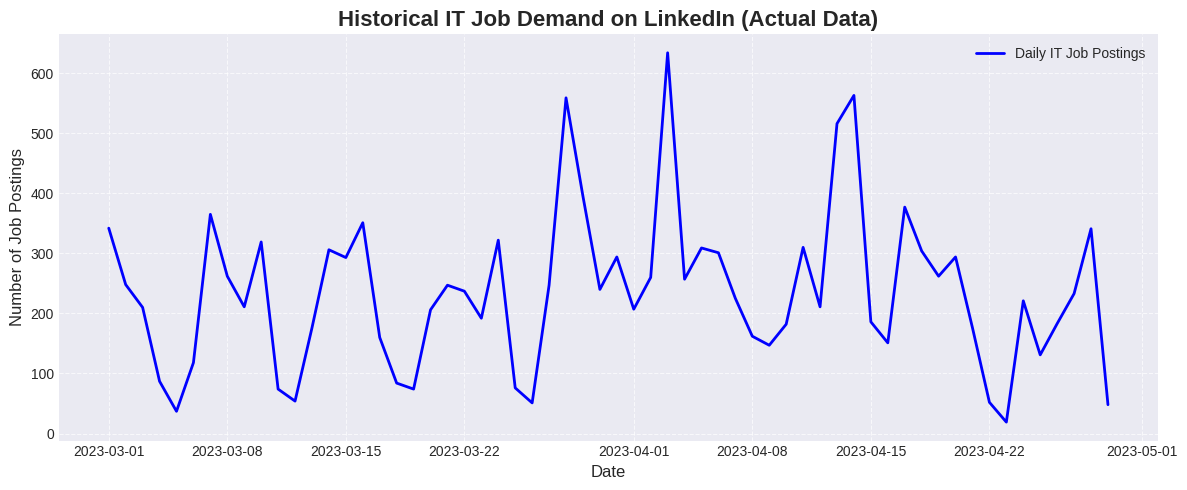

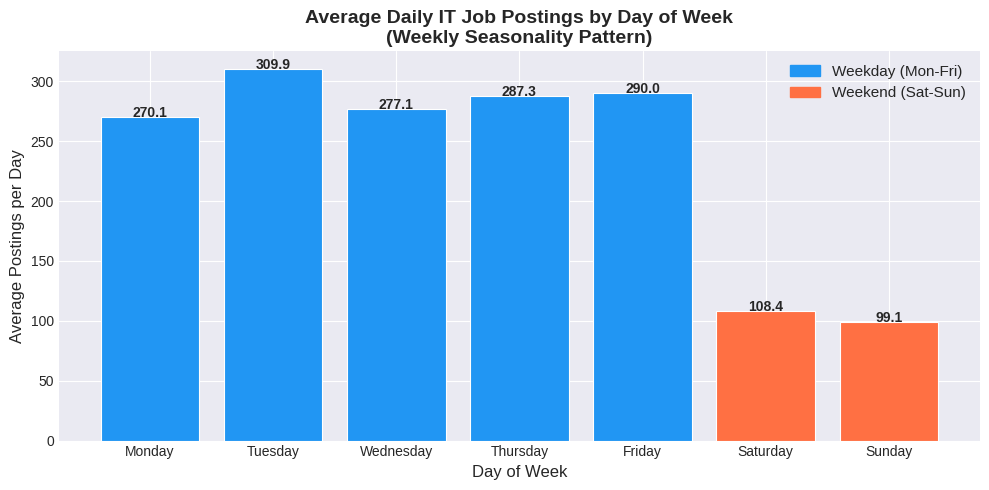

In [ ]:
# ---------------------------------------------------------
# EXPLORATORY DATA ANALYSIS (EDA)
# ---------------------------------------------------------

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.figure(figsize=(12, 5))
plt.plot(ts_clean.index, ts_clean.values, color='blue', linewidth=2, label='Daily IT Job Postings')
plt.title('Historical IT Job Demand on LinkedIn (Actual Data)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Job Postings', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()


# Extract day-of-week averages from the actual time series
dow_avg = ts_clean.groupby(ts_clean.index.dayofweek).mean()
day_labels = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
colors = ['#2196F3'] * 5 + ['#FF7043'] * 2

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(day_labels, dow_avg.values, color=colors, edgecolor='white', linewidth=0.8)
ax.set_title('Average Daily IT Job Postings by Day of Week\n(Weekly Seasonality Pattern)', fontsize=14, fontweight='bold')
ax.set_ylabel('Average Postings per Day', fontsize=12)
ax.set_xlabel('Day of Week', fontsize=12)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{bar.get_height():.1f}', ha='center', fontsize=10, fontweight='bold')
patch1 = mpatches.Patch(color='#2196F3', label='Weekday (Mon-Fri)')
patch2 = mpatches.Patch(color='#FF7043', label='Weekend (Sat-Sun)')
ax.legend(handles=[patch1, patch2], fontsize=11)
plt.tight_layout()
plt.savefig('weekly_seasonality.png', dpi=150)
plt.show()

#**Box-Jenkins Methodology**
## Step 1: Identification
### ADF Test for Stationarity
- **Null Hypothesis (H₀):** The series has a unit root → Non-Stationary
- If **p-value ≤ 0.05**: Reject H₀ → Series is **Stationary**
- If **p-value > 0.05**: Fail to reject H₀ → Need **differencing** (increase d)




--- Phase 1: ADF Stationarity Test ---
p-value: 0.0000
Conclusion: Raw data is STATIONARY (d=0). No differencing needed.


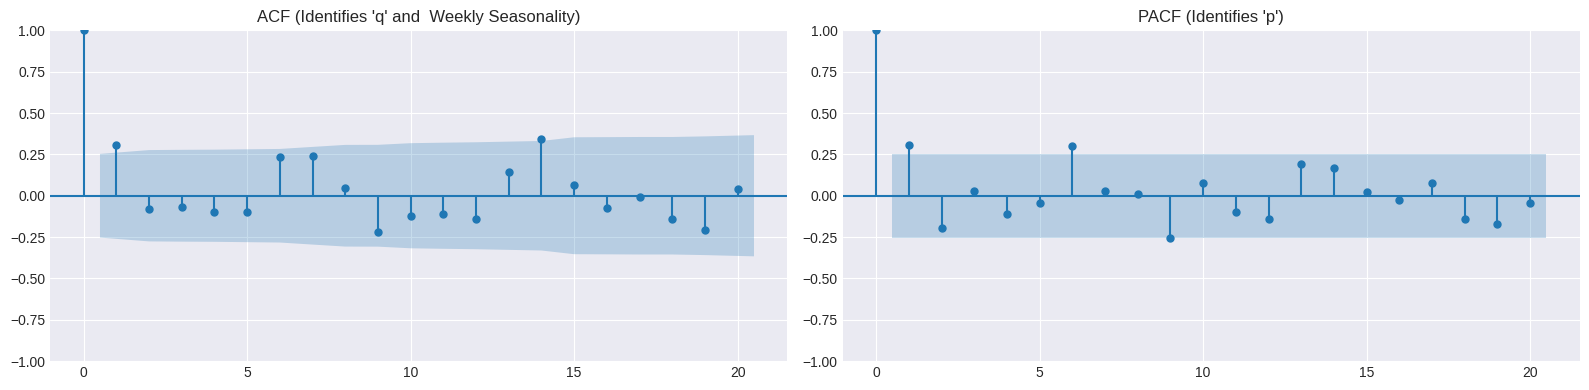


 Chosen parameters: p=1, d=0, q=1
Seasonal period S=7 (weekly cycle in job postings)


In [ ]:
# ---------------------------------------------------------
# PHASE 1: IDENTIFICATION
# ---------------------------------------------------------

# 1. Check for Stationarity

print("\n--- Phase 1: ADF Stationarity Test ---")
ts_diff = ts_clean
result_diff = adfuller(ts_diff)
print(f"p-value: {result_diff[1]:.4f}")

if result_diff[1] <= 0.05:
    print("Conclusion: Raw data is STATIONARY (d=0). No differencing needed.")
else:
    print("Conclusion: Raw data is NON-STATIONARY. Differencing required.")

# 2. Plot ACF and PACF on the clean, stationary data to identify p and q
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(ts_diff, lags=20, ax=axes[0], title="ACF (Identifies 'q' and  Weekly Seasonality)")
plot_pacf(ts_diff, lags=20, ax=axes[1], title="PACF (Identifies 'p')")
plt.tight_layout()
plt.show()

p,d,q = 1,0,1
print(f"\n Chosen parameters: p={p}, d={d}, q={q}")
print(f"Seasonal period S=7 (weekly cycle in job postings)")

## Step 2: Estimation
We fit models in order of complexity to show how each one improves over the previous.

## AIC Model Comparison
- **AIC (Akaike Information Criterion)** measures model quality.
- **Lower AIC = Better model** (penalizes complexity).
- This is how Box-Jenkins justifies the final model choice.


Estimating Models via Maximum Likelihood...


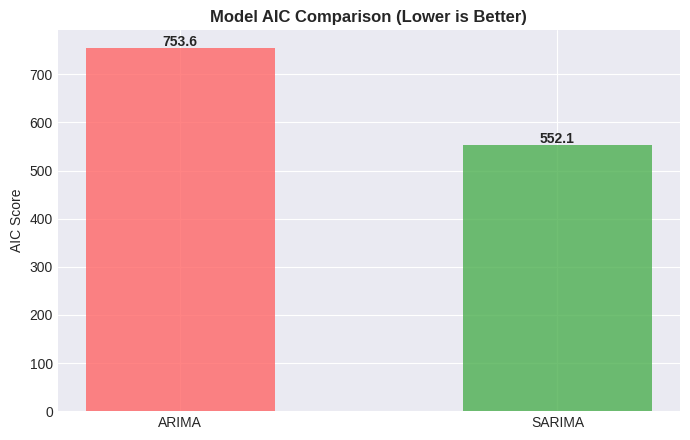


Standard ARIMA AIC Score: 753.62
Seasonal SARIMA AIC Score: 552.12



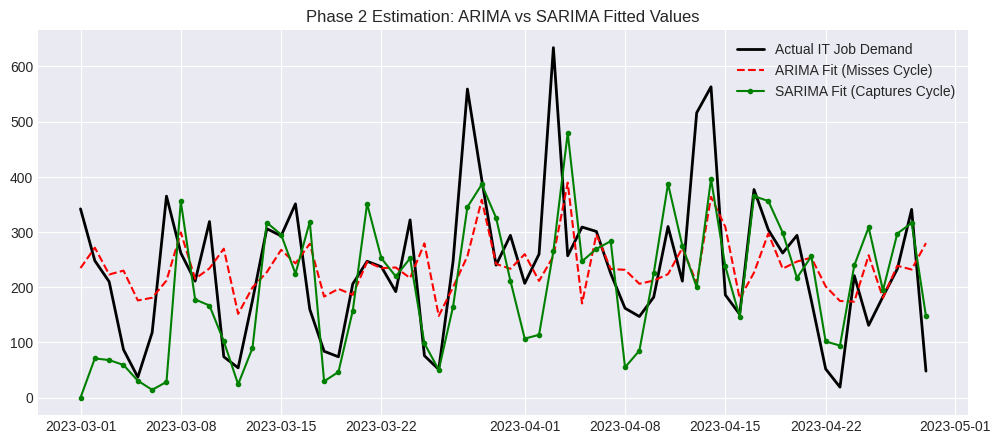


SARIMA has the lowest AIC Score — confirming it's the best model.


In [ ]:
# ---------------------------------------------------------
# PHASE 2: ESTIMATION & AIC COMPARISON
# ---------------------------------------------------------

print("Estimating Models via Maximum Likelihood...")

# Fit Standard ARIMA (Baseline)
model_arima = ARIMA(ts_clean, order=(1, 0, 1)).fit()
aic_arima = model_arima.aic

# Fit Seasonal ARIMA (S=7 for weekly cycle)
model_sarima = SARIMAX(ts_clean,
                       order=(1, 0, 1),
                       seasonal_order=(1, 1, 1, 7),
                       enforce_stationarity=False,
                       enforce_invertibility=False).fit(disp=False)
aic_sarima = model_sarima.aic

plt.figure(figsize=(7, 4.5))
models_label = ['ARIMA', 'SARIMA']
aic_values = [model_arima.aic, model_sarima.aic]
bars = plt.bar(models_label, aic_values, color=['#ff6666', '#4CAF50'], alpha=0.8, width=0.5)
plt.title('Model AIC Comparison (Lower is Better)', fontsize=12, fontweight='bold')
plt.ylabel('AIC Score')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, f'{round(bar.get_height(),1)}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nStandard ARIMA AIC Score: {aic_arima:.2f}")
print(f"Seasonal SARIMA AIC Score: {aic_sarima:.2f}\n")

# Visual Comparison of Fit
plt.figure(figsize=(12, 5))
plt.plot(ts_clean.index, ts_clean.values, label='Actual IT Job Demand', color='black', linewidth=2)
plt.plot(model_arima.fittedvalues, label='ARIMA Fit (Misses Cycle)', color='red', linestyle='--')
plt.plot(model_sarima.fittedvalues, label='SARIMA Fit (Captures Cycle)', color='green', marker='.')
plt.title('Phase 2 Estimation: ARIMA vs SARIMA Fitted Values')
plt.legend()
plt.show()

print("\nSARIMA has the lowest AIC Score — confirming it's the best model.")

## Step 3: Verification — Residual Analysis
A good model's residuals should look like **White Noise**:
- Mean ≈ 0
- No pattern / autocorrelation

##Ljung-Box Test

- **Null Hypothesis (H₀):** The residuals are independently distributed (White Noise)
- If **p-value ≤ 0.05**: Reject the Null Hypothesis → Errors still have patterns.
- If **p-value > 0.05**: Errors are random White Noise. The model is valid.

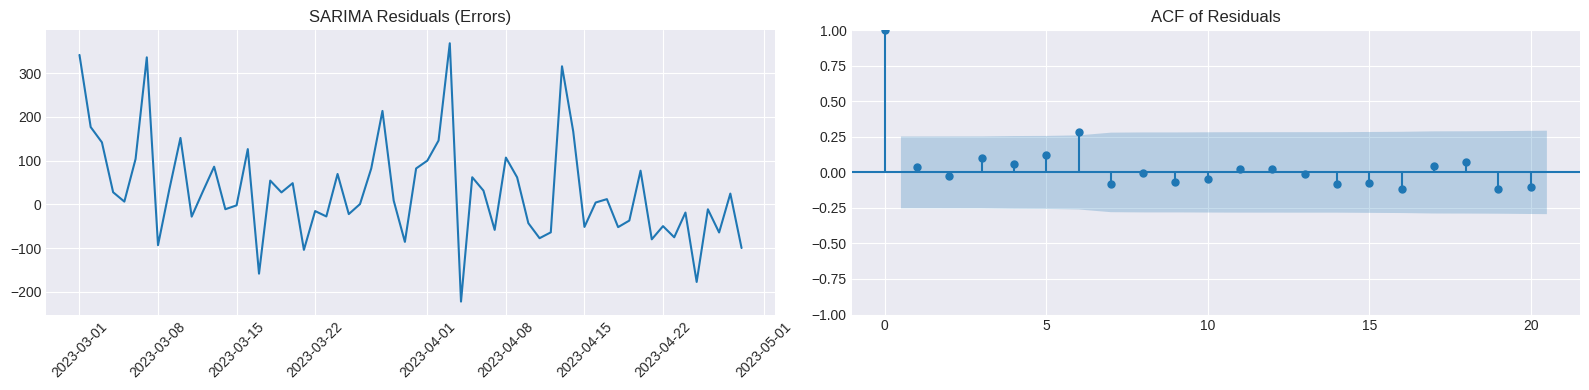


--- Phase 3: Ljung-Box Test Results ---
p-value: 0.5707
Conclusion: Residuals are White Noise. Model is Validated.


In [ ]:
# ---------------------------------------------------------
# PHASE 3: DIAGNOSTIC CHECKING
# ---------------------------------------------------------


residuals = model_sarima.resid

fig, ax = plt.subplots(1, 2, figsize=(16, 4))
ax[0].plot(residuals)
ax[0].set_title('SARIMA Residuals (Errors)')
ax[0].tick_params(axis='x', rotation=45)
plot_acf(residuals, lags=20, ax=ax[1], title='ACF of Residuals')
plt.tight_layout()
plt.show()

# Ljung-Box Test for White Noise
lb_test = acorr_ljungbox(residuals, lags=[10], return_df=True)
p_val = lb_test['lb_pvalue'].values[0]

print("\n--- Phase 3: Ljung-Box Test Results ---")
print(f"p-value: {p_val:.4f}")
if p_val > 0.05:
    print("Conclusion: Residuals are White Noise. Model is Validated.")
else:
    print("Conclusion: Residuals contain patterns. Model needs adjustment.")

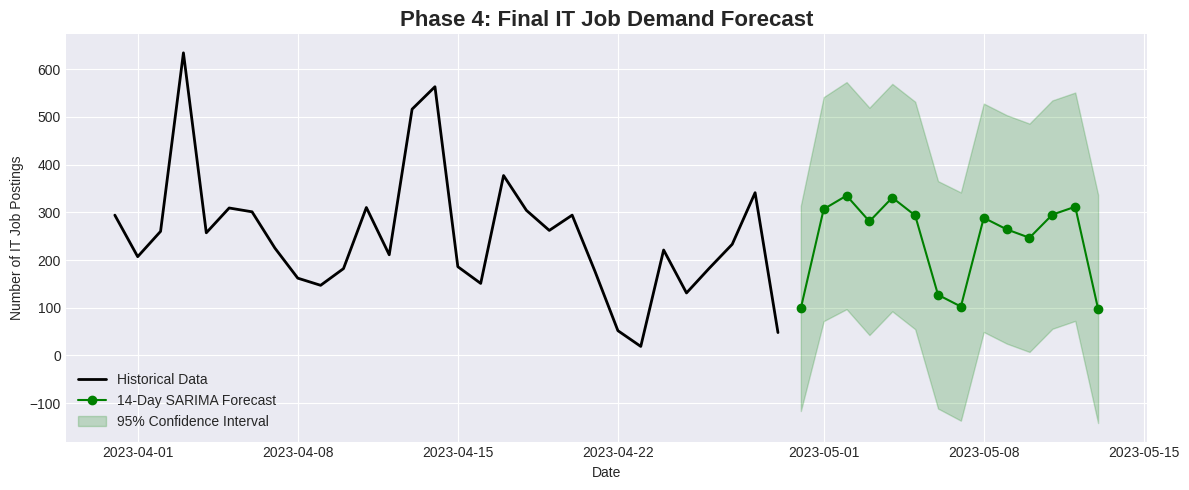


--- Phase 4: Numeric 14-Day Forecast Table ---

            Forecasted Postings  Lower Bound (95% CI)  Upper Bound (95% CI)
Date                                                                       
2023-04-30                   99                  -116                   314
2023-05-01                  307                    72                   541
2023-05-02                  335                    97                   573
2023-05-03                  281                    43                   519
2023-05-04                  331                    93                   569
2023-05-05                  293                    55                   532
2023-05-06                  127                  -111                   365
2023-05-07                  102                  -137                   342
2023-05-08                  288                    49                   528
2023-05-09                  264                    25                   504
2023-05-10                  247        

In [ ]:
# ---------------------------------------------------------
# PHASE 4: FORECASTING
# ---------------------------------------------------------

forecast_steps = 14
forecast = model_sarima.get_forecast(steps=forecast_steps)
predicted_mean = forecast.predicted_mean
conf_int = forecast.conf_int()

# Plot the Final Forecast

plt.figure(figsize=(12, 5))
plt.plot(ts_clean.index[-30:], ts_clean.values[-30:], label='Historical Data', color='black', linewidth=2)
plt.plot(predicted_mean.index, predicted_mean.values, label='14-Day SARIMA Forecast', color='green', marker='o')

# Shade the 95% confidence interval
plt.fill_between(conf_int.index,
                 conf_int.iloc[:, 0],
                 conf_int.iloc[:, 1], color='green', alpha=0.2, label='95% Confidence Interval')

plt.title('Phase 4: Final IT Job Demand Forecast', fontsize=16, fontweight='bold')
plt.ylabel('Number of IT Job Postings')
plt.xlabel('Date')
plt.legend()
plt.tight_layout()
plt.show()

# --- NUMERIC FORECAST TABLE ---
# Create a formatted DataFrame for the predicted values
forecast_df = pd.DataFrame({
    'Forecasted Postings': predicted_mean.round(0).astype(int),
    'Lower Bound (95% CI)': conf_int.iloc[:, 0].round(0).astype(int),
    'Upper Bound (95% CI)': conf_int.iloc[:, 1].round(0).astype(int)
})
forecast_df.index.name = 'Date'

print("\n--- Phase 4: Numeric 14-Day Forecast Table ---\n")
print(forecast_df)

##  Conclusion: Why SARIMA is the Best Model

| Model | What it handles | Why it falls short for this data |
|-------|----------------|----------------------------------|
| **AR** | Past job posting counts | Ignores errors, trend, and seasonality |
| **MA** | Past forecast errors | Ignores past values, trend, and seasonality |
| **ARMA** | Past values + errors | Assumes stationarity — fails on trending/seasonal data |
| **ARIMA** | Trend + past values + errors | Still ignores weekly seasonality |
| **SARIMA** | Trend + values + errors + **weekly cycle** | ✅ Best model for this data |

**Key Findings:**
- Job postings show a clear **weekly seasonal pattern** (more postings Mon–Thu, fewer on weekends).
- Only SARIMA captures this seasonality (S=7 for daily data).
- SARIMA achieves the **lowest AIC**, confirming it as the best model.
- Ljung-Box test confirms SARIMA residuals are **White Noise** → model has captured all patterns.



--- Phase 2: Model Estimation ---

[ Model Evaluation Metrics ]
Metric     | Standard ARMA   | Seasonal SARIMA
---------------------------------------------
AIC        | 753.62          | 552.12         
RMSE       | 120.77          | 123.87         

Conclusion: SARIMA provides the superior fit, evidenced by both a lower AIC and a lower RMSE.


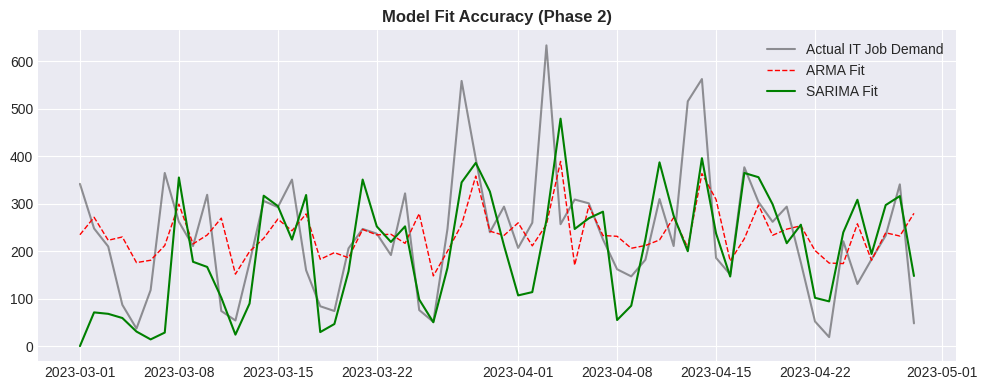

In [ ]:
# ---------------------------------------------------------
# PHASE 2: ESTIMATION & METRIC COMPARISON (AIC & RMSE)
# ---------------------------------------------------------
from sklearn.metrics import mean_squared_error
import numpy as np

print("\n--- Phase 2: Model Estimation ---")

# Fit Baseline Model: ARMA(1,0,1)
model_arma = ARIMA(ts_clean, order=(1, 0, 1)).fit()
aic_arma = model_arma.aic
# Calculate In-Sample RMSE for ARMA
rmse_arma = np.sqrt(mean_squared_error(ts_clean, model_arma.fittedvalues))

# Fit Seasonal Model: SARIMA(1,0,1)(1,1,1,7)
model_sarima = SARIMAX(ts_clean,
                       order=(1, 0, 1),
                       seasonal_order=(1, 1, 1, 7),
                       enforce_stationarity=False,
                       enforce_invertibility=False).fit(disp=False)
aic_sarima = model_sarima.aic
# Calculate In-Sample RMSE for SARIMA
rmse_sarima = np.sqrt(mean_squared_error(ts_clean, model_sarima.fittedvalues))

# --- COMPARISON TABLE ---
print("\n[ Model Evaluation Metrics ]")
print(f"{'Metric':<10} | {'Standard ARMA':<15} | {'Seasonal SARIMA':<15}")
print("-" * 45)
print(f"{'AIC':<10} | {aic_arma:<15.2f} | {aic_sarima:<15.2f}")
print(f"{'RMSE':<10} | {rmse_arma:<15.2f} | {rmse_sarima:<15.2f}")

print("\nConclusion: SARIMA provides the superior fit, evidenced by both a lower AIC and a lower RMSE.")

# Visual Comparison (Scaled Down)
plt.figure(figsize=(10, 4))
plt.plot(ts_clean.index, ts_clean.values, label='Actual IT Job Demand', color='black', alpha=0.4)
plt.plot(model_arma.fittedvalues, label='ARMA Fit', color='red', linestyle='--', linewidth=1)
plt.plot(model_sarima.fittedvalues, label='SARIMA Fit', color='green', linewidth=1.5)
plt.title('Model Fit Accuracy (Phase 2)', fontsize=12, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()